# Sales Demand Forecasting - EDA & ML Modeling
**Tech Stack:** Python, Pandas, Seaborn, Scikit-learn


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')
print('All libraries loaded successfully!')

All libraries loaded successfully!


## 1. Load & Explore Data

In [12]:
df = pd.read_csv('../data/sales_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['DayOfWeek'] = df['Date'].dt.dayofweek
print('Shape:', df.shape)
df.head()

Shape: (1000, 13)


,Date,Product,Category,Region,Units_Sold,Unit_Price,Revenue,Discount,Customer_Age,Customer_Gender,Month,Year,DayOfWeek
0,2023-10-17,Laptop,Electronics,East,16,1193.73,14897.75,0.22,61,Male,10,2023,1
1,2023-08-28,Chair,Furniture,North,6,1171.33,5973.78,0.15,19,Male,8,2023,0
2,2023-10-28,Gym Kit,Sports,South,29,2987.40,65842.30,0.24,18,Male,10,2023,5
3,2023-12-16,Sofa,Furniture,East,10,1155.04,8893.81,0.23,24,Male,12,2023,5
4,2023-01-25,Tablet,Electronics,East,39,1396.15,53905.35,0.01,47,Male,1,2023,2


In [13]:
print('Dataset Info:')
df.info()
print('\nMissing Values:')
print(df.isnull().sum())
print('\nBasic Statistics:')
df.describe()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             1000 non-null   datetime64[us]
 1   Product          1000 non-null   str           
 2   Category         1000 non-null   str           
 3   Region           1000 non-null   str           
 4   Units_Sold       1000 non-null   int64         
 5   Unit_Price       1000 non-null   float64       
 6   Revenue          1000 non-null   float64       
 7   Discount         1000 non-null   float64       
 8   Customer_Age     1000 non-null   int64         
 9   Customer_Gender  1000 non-null   str           
 10  Month            1000 non-null   int32         
 11  Year             1000 non-null   int32         
 12  DayOfWeek        1000 non-null   int32         
dtypes: datetime64[us](1), float64(3), int32(3), int64(2), str(4)
memory usage: 112.3 KB

Missin

,Date,Units_Sold,Unit_Price,Revenue,Discount,Customer_Age,Month,Year,DayOfWeek
count,1000,1000.000000,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000
mean,2023-01-11 04:13:26.400000,25.998000,2538.675460,56856.52182,0.14766,41.974000,6.558000,2022.528000,2.91800
min,2022-01-01 00:00:00,1.000000,108.810000,628.94000,0.00000,18.000000,1.000000,2022.000000,0.00000
25%,2022-07-06 18:00:00,13.000000,1310.430000,15812.88500,0.07000,30.000000,4.000000,2022.000000,1.00000
50%,2023-01-20 00:00:00,27.000000,2536.340000,43929.69500,0.15000,42.500000,7.000000,2023.000000,3.00000
75%,2023-07-13 06:00:00,38.000000,3755.085000,85466.04750,0.22000,53.000000,10.000000,2023.000000,5.00000
max,2024-01-01 00:00:00,50.000000,4990.220000,227044.32000,0.30000,65.000000,12.000000,2024.000000,6.00000
std,NaN,14.397892,1410.089363,48489.19154,0.08572,13.562716,3.421746,0.503458,1.98928


## 2. Exploratory Data Analysis (EDA)

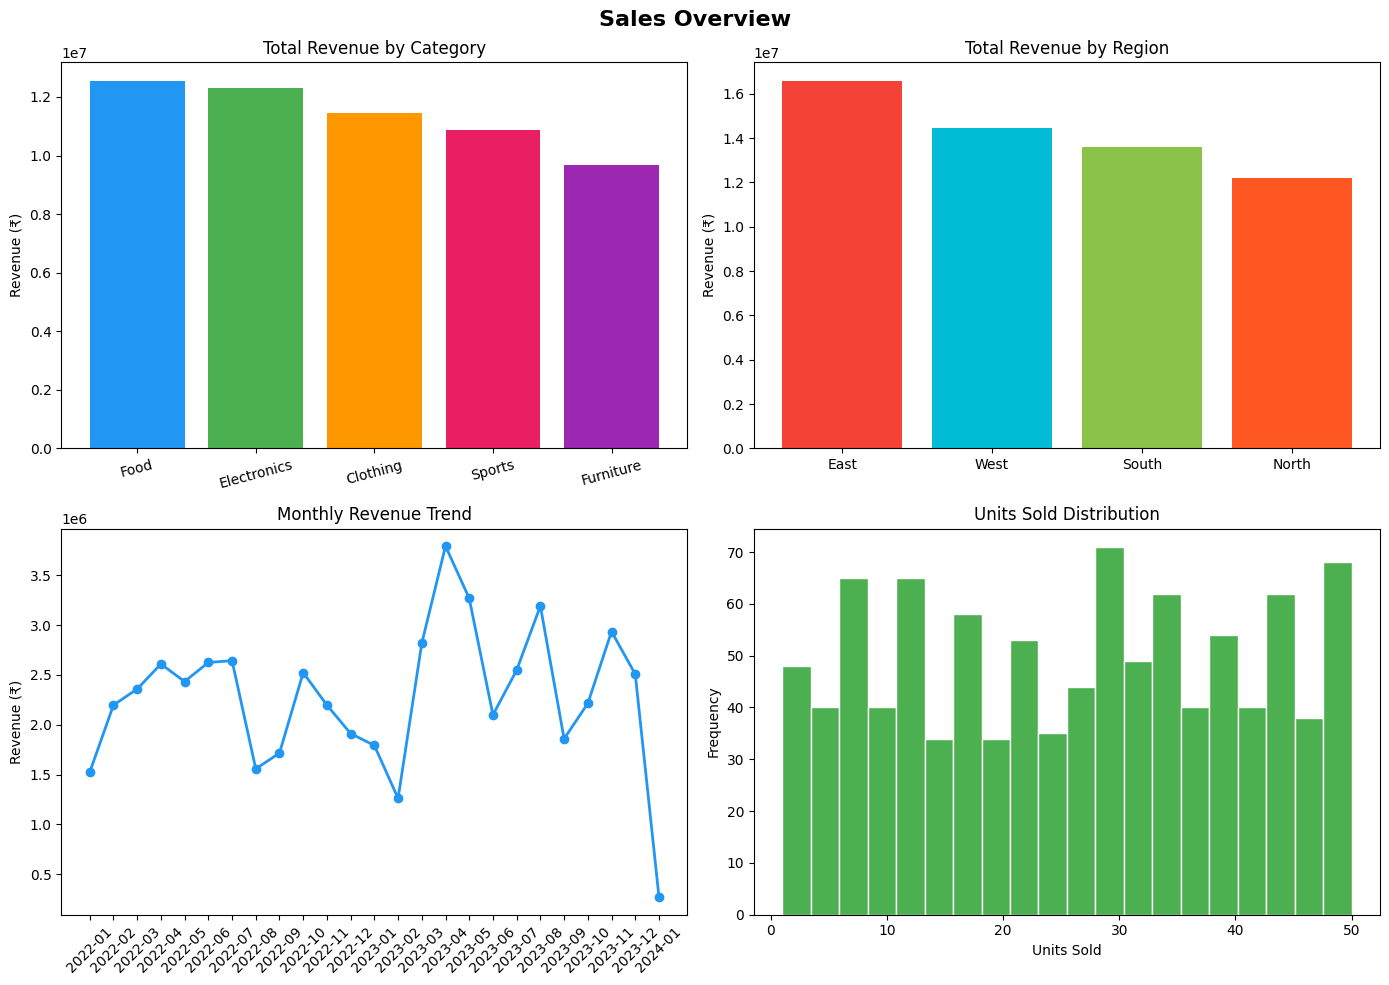

Chart saved!


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Sales Overview', fontsize=16, fontweight='bold')

# Revenue by Category
cat_rev = df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)
axes[0,0].bar(cat_rev.index, cat_rev.values, color=['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0'])
axes[0,0].set_title('Total Revenue by Category')
axes[0,0].set_ylabel('Revenue (₹)')
axes[0,0].tick_params(axis='x', rotation=15)

# Revenue by Region
reg_rev = df.groupby('Region')['Revenue'].sum().sort_values(ascending=False)
axes[0,1].bar(reg_rev.index, reg_rev.values, color=['#F44336','#00BCD4','#8BC34A','#FF5722'])
axes[0,1].set_title('Total Revenue by Region')
axes[0,1].set_ylabel('Revenue (₹)')

# Monthly Revenue Trend
monthly = df.groupby(['Year','Month'])['Revenue'].sum().reset_index()
monthly['Period'] = monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str).str.zfill(2)
axes[1,0].plot(monthly['Period'], monthly['Revenue'], marker='o', color='#2196F3', linewidth=2)
axes[1,0].set_title('Monthly Revenue Trend')
axes[1,0].set_ylabel('Revenue (₹)')
axes[1,0].tick_params(axis='x', rotation=45)

# Units Sold Distribution
axes[1,1].hist(df['Units_Sold'], bins=20, color='#4CAF50', edgecolor='white')
axes[1,1].set_title('Units Sold Distribution')
axes[1,1].set_xlabel('Units Sold')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../data/sales_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')

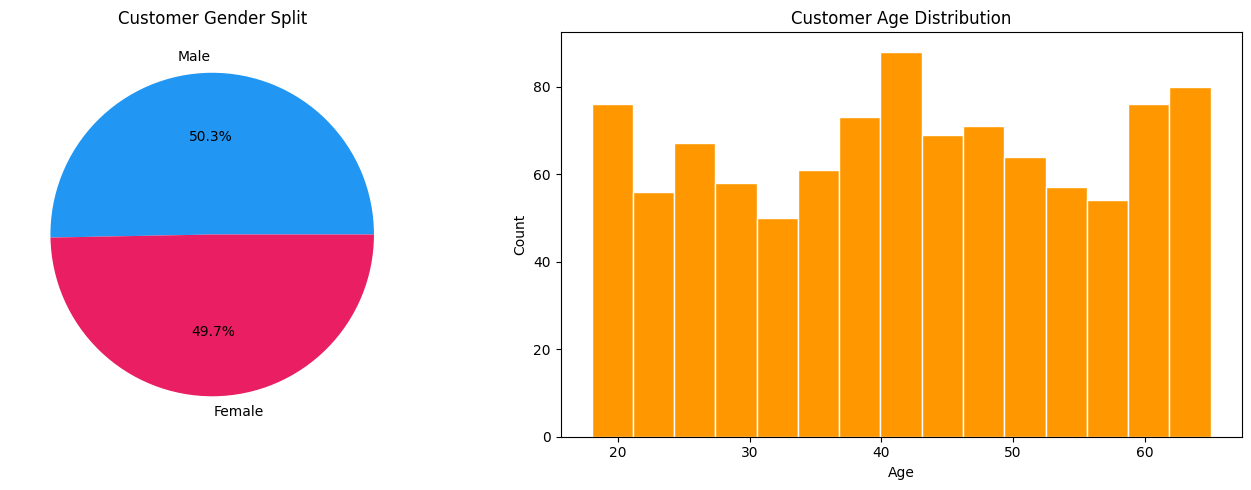

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender split
gender = df['Customer_Gender'].value_counts()
axes[0].pie(gender.values, labels=gender.index, autopct='%1.1f%%', colors=['#2196F3','#E91E63'])
axes[0].set_title('Customer Gender Split')

# Age distribution
axes[1].hist(df['Customer_Age'], bins=15, color='#FF9800', edgecolor='white')
axes[1].set_title('Customer Age Distribution')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

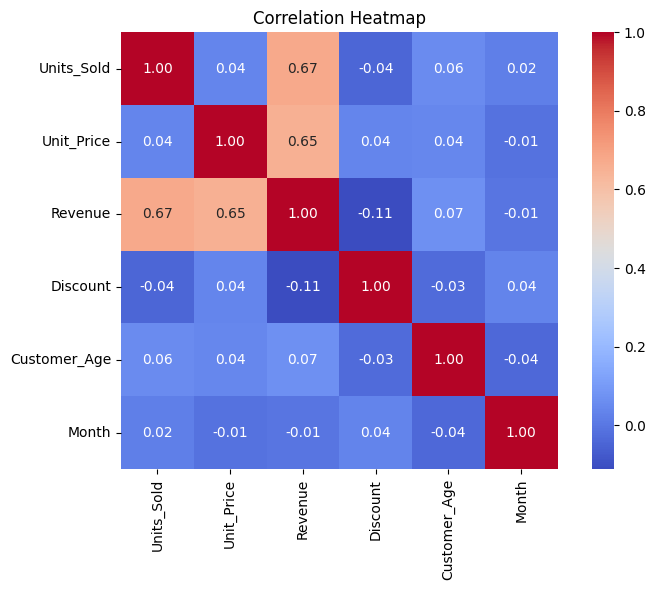

In [16]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
numeric_cols = ['Units_Sold', 'Unit_Price', 'Revenue', 'Discount', 'Customer_Age', 'Month']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 3. Machine Learning - Revenue Prediction

In [17]:
# Feature Engineering
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_ml = df.copy()
df_ml['Category_enc'] = le.fit_transform(df_ml['Category'])
df_ml['Region_enc'] = le.fit_transform(df_ml['Region'])
df_ml['Gender_enc'] = le.fit_transform(df_ml['Customer_Gender'])

features = ['Units_Sold', 'Unit_Price', 'Discount', 'Customer_Age', 'Month', 'DayOfWeek', 'Category_enc', 'Region_enc', 'Gender_enc']
X = df_ml[features]
y = df_ml['Revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train size:', X_train.shape)
print('Test size:', X_test.shape)

Train size: (800, 9)
Test size: (200, 9)


In [18]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)
print(f'Linear Regression  -> MAE: {lr_mae:.2f} | R2 Score: {lr_r2:.4f}')

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)
print(f'Random Forest      -> MAE: {rf_mae:.2f} | R2 Score: {rf_r2:.4f}')

Linear Regression  -> MAE: 13761.13 | R2 Score: 0.8495
Random Forest      -> MAE: 3398.41 | R2 Score: 0.9884


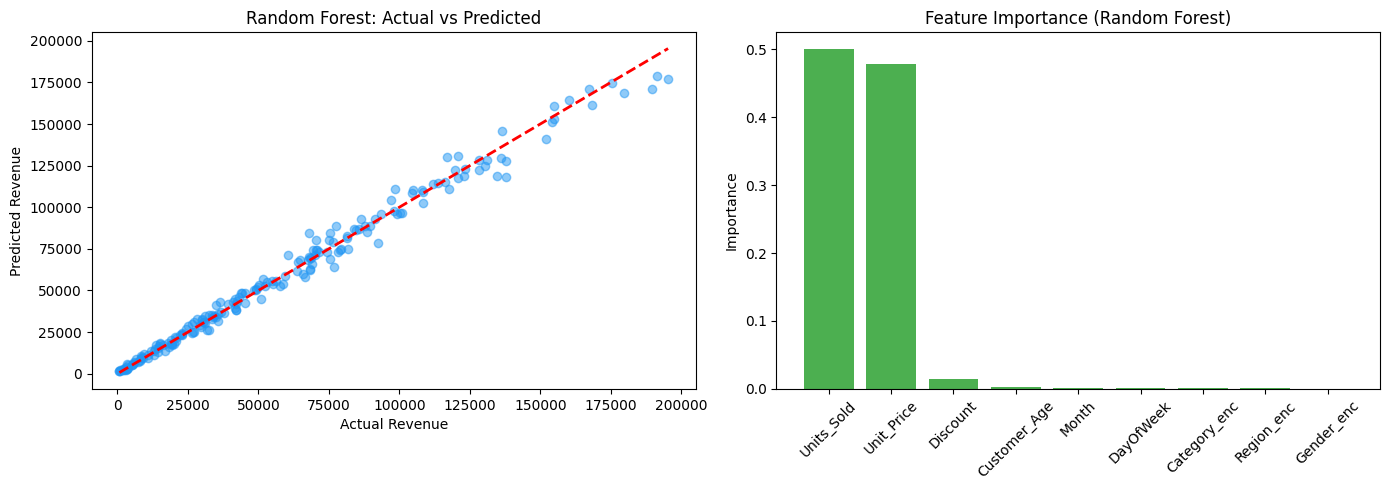


Best Model: Random Forest (R2=0.9884)


In [19]:
# Model Comparison Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted - Random Forest
axes[0].scatter(y_test, rf_pred, alpha=0.5, color='#2196F3')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Random Forest: Actual vs Predicted')
axes[0].set_xlabel('Actual Revenue')
axes[0].set_ylabel('Predicted Revenue')

# Feature Importance
feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
axes[1].bar(feat_imp.index, feat_imp.values, color='#4CAF50')
axes[1].set_title('Feature Importance (Random Forest)')
axes[1].set_ylabel('Importance')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f'\nBest Model: Random Forest (R2={rf_r2:.4f})')

In [20]:
# Save the model
import pickle
with open('../models/model.pkl', 'wb') as f:
    pickle.dump(rf, f)
print('Model saved to models/model.pkl')

Model saved to models/model.pkl
